In [ ]:
#ARIMA application for stock

In [ ]:
import pandas as pd

# Load the CSV file. Assuming the file is named 'HistoricalQuotes.csv'
# If your file has a different name, please replace 'HistoricalQuotes.csv' with the correct filename.
df = pd.read_csv('NIFTY_50_5m_5Y.csv')

# Convert 'date' column to datetime and set as index
# The date column is named 'date' (lowercase)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Sort the DataFrame by index in ascending order
df = df.sort_index()

# Remove duplicate index entries, keeping the first occurrence
df = df[~df.index.duplicated(keep='first')]

# Set the frequency of the DatetimeIndex to 5 minutes ('5T')
# This is crucial for statsmodels to correctly handle forecasting with a date index.
df = df.dropna(subset=['close'])

# Display the first 5 rows and DataFrame information
print(df.head())
print(df.info())

                               open      high       low     close  volume
date                                                                     
2021-01-25 09:15:00+05:30  14477.80  14490.10  14437.35  14445.70       0
2021-01-25 09:20:00+05:30  14445.55  14478.00  14445.55  14453.80       0
2021-01-25 09:25:00+05:30  14452.90  14468.05  14440.10  14449.25       0
2021-01-25 09:30:00+05:30  14448.55  14467.45  14430.70  14441.50       0
2021-01-25 09:35:00+05:30  14439.25  14440.90  14395.60  14405.15       0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 92411 entries, 2021-01-25 09:15:00+05:30 to 2026-01-22 11:55:00+05:30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    92411 non-null  float64
 1   high    92411 non-null  float64
 2   low     92411 non-null  float64
 3   close   92411 non-null  float64
 4   volume  92411 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 4.2 MB
None


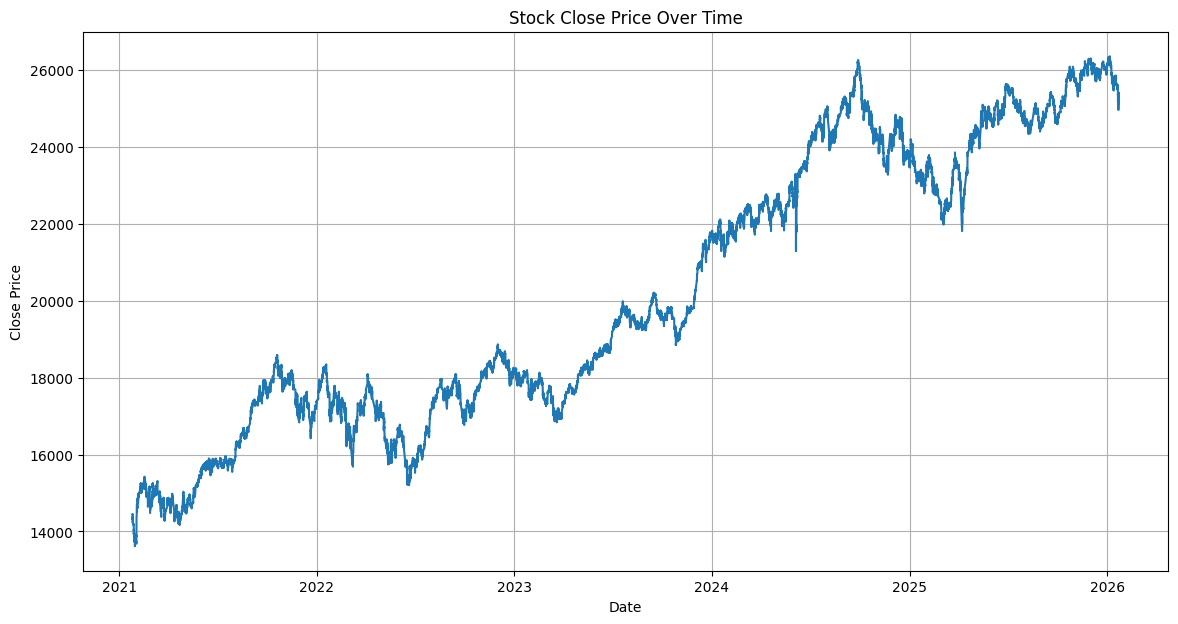

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Visualize the time series of 'close' prices
plt.figure(figsize=(14, 7))
sns.lineplot(x=df.index, y='close', data=df)
plt.title('Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

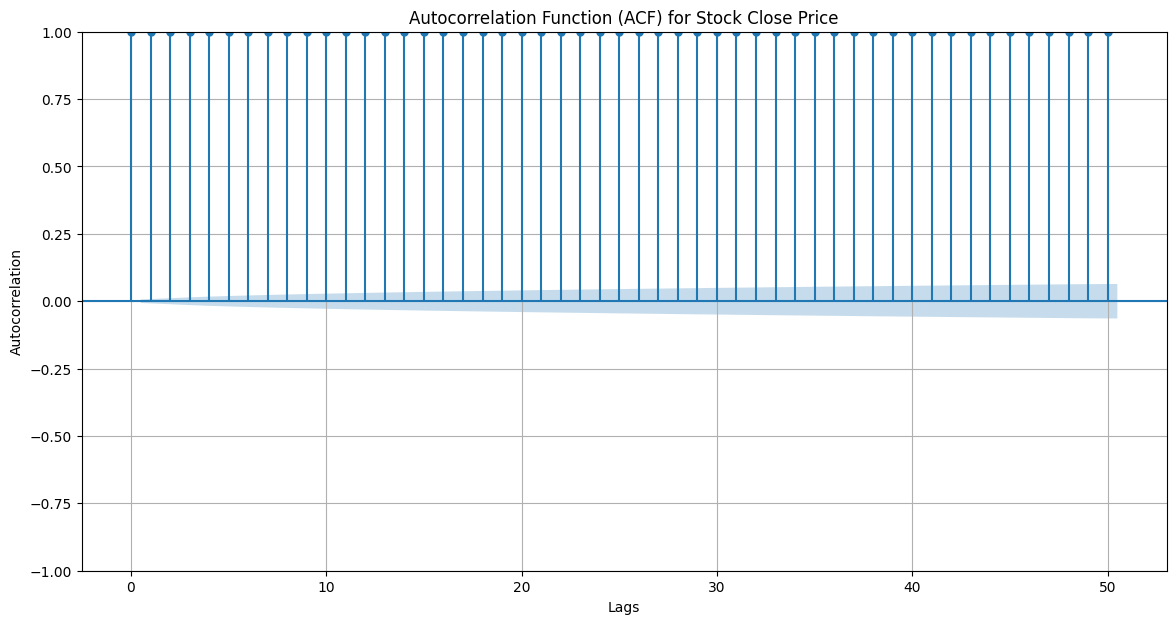

In [ ]:
# Plot ACF
plt.figure(figsize=(14, 7))
plot_acf(df['close'], lags=50, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) for Stock Close Price')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

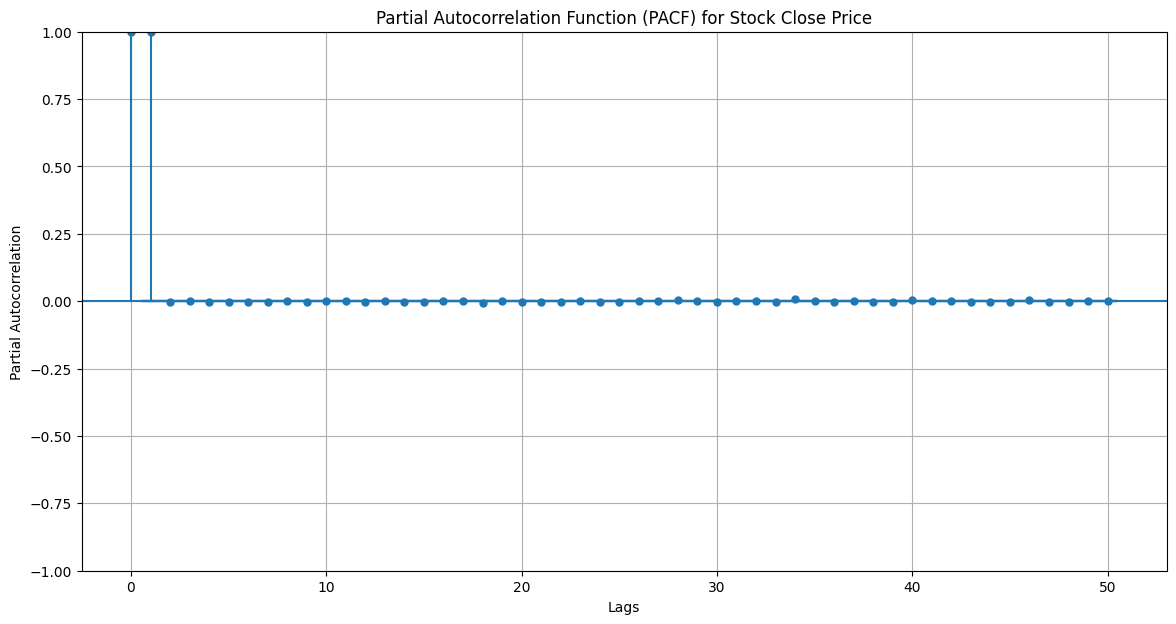

In [ ]:
# Plot PACF
plt.figure(figsize=(14, 7))
plot_pacf(df['close'], lags=50, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) for Stock Close Price')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

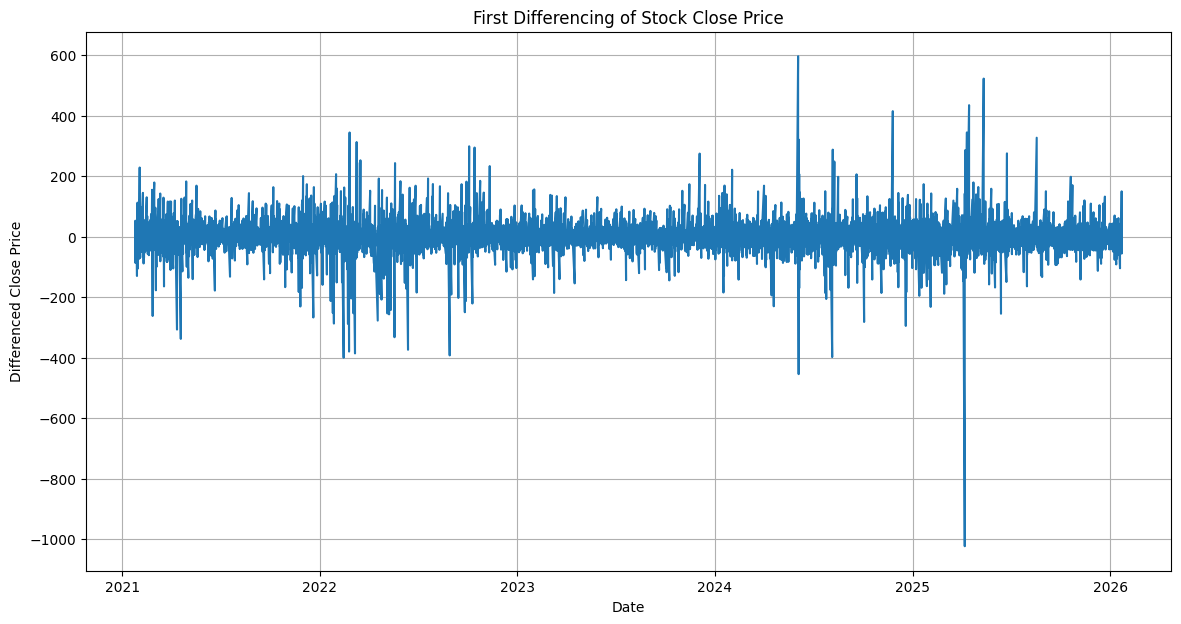

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the first difference of the 'close' price
df_diff = df['close'].diff().dropna()

# Plot the differenced series
plt.figure(figsize=(14, 7))
sns.lineplot(x=df_diff.index, y=df_diff)
plt.title('First Differencing of Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    # Dickey-Fuller test
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    # Check p-value
    if dfoutput['p-value'] <= 0.05:
        print("\nConclusion: The time series is likely stationary (p-value <= 0.05).")
    else:
        print("\nConclusion: The time series is likely non-stationary (p-value > 0.05). Differencing may be required.")

# Perform ADF test on the first differenced 'close' price series
print("Checking stationarity for the first differenced 'close' price:")
check_stationarity(df_diff)

Checking stationarity for the first differenced 'close' price:
Results of Dickey-Fuller Test:
Test Statistic                   -86.038088
p-value                            0.000000
#Lags Used                        11.000000
Number of Observations Used    92398.000000
Critical Value (1%)               -3.430421
Critical Value (5%)               -2.861571
Critical Value (10%)              -2.566787
dtype: float64

Conclusion: The time series is likely stationary (p-value <= 0.05).


/tmp/ipykernel_564/482785328.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  dftest = adfuller(timeseries, autolag='AIC')


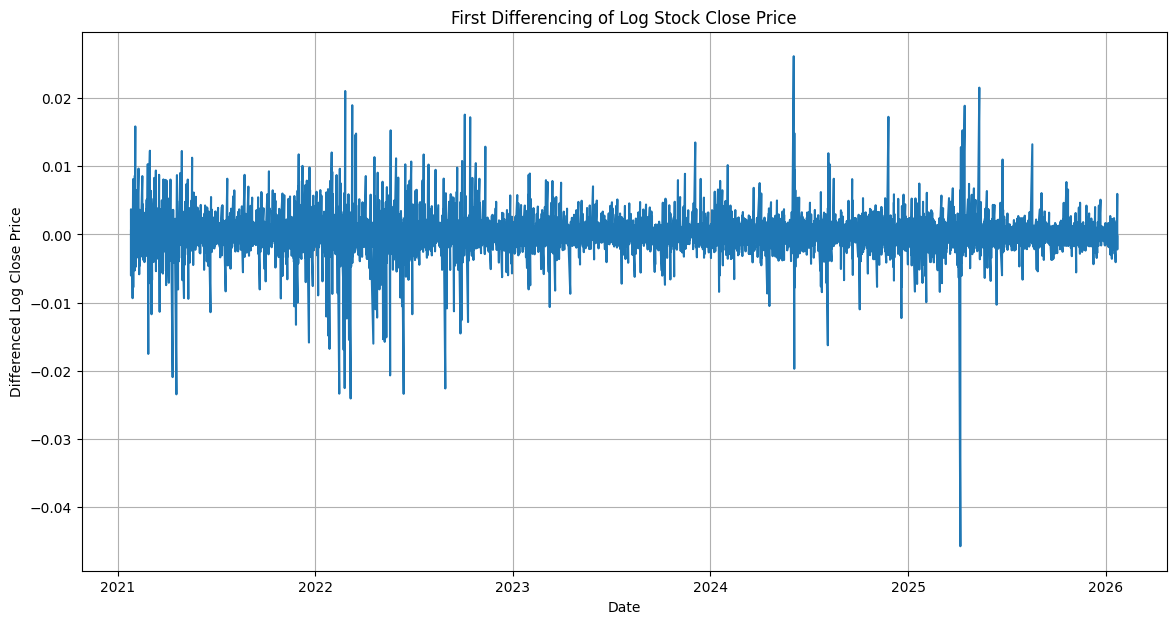

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the natural logarithm of the 'close' price
df['log_close'] = np.log(df['close'])

# Calculate the first difference of the log-transformed series
df_log_diff = df['log_close'].diff().dropna()

# Plot the differenced log series
plt.figure(figsize=(14, 7))
sns.lineplot(x=df_log_diff.index, y=df_log_diff)
plt.title('First Differencing of Log Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Differenced Log Close Price')
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    # Dickey-Fuller test
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    # Check p-value
    if dfoutput['p-value'] <= 0.05:
        print("\nConclusion: The time series is likely stationary (p-value <= 0.05).")
    else:
        print("\nConclusion: The time series is likely non-stationary (p-value > 0.05). Differencing may be required.")

# Perform ADF test on the first differenced log 'close' price series
print("Checking stationarity for the first differenced log 'close' price:")
check_stationarity(df_log_diff)

Checking stationarity for the first differenced log 'close' price:
Results of Dickey-Fuller Test:
Test Statistic                   -85.764871
p-value                            0.000000
#Lags Used                        11.000000
Number of Observations Used    92398.000000
Critical Value (1%)               -3.430421
Critical Value (5%)               -2.861571
Critical Value (10%)              -2.566787
dtype: float64

Conclusion: The time series is likely stationary (p-value <= 0.05).


/tmp/ipykernel_564/2486296329.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  dftest = adfuller(timeseries, autolag='AIC')


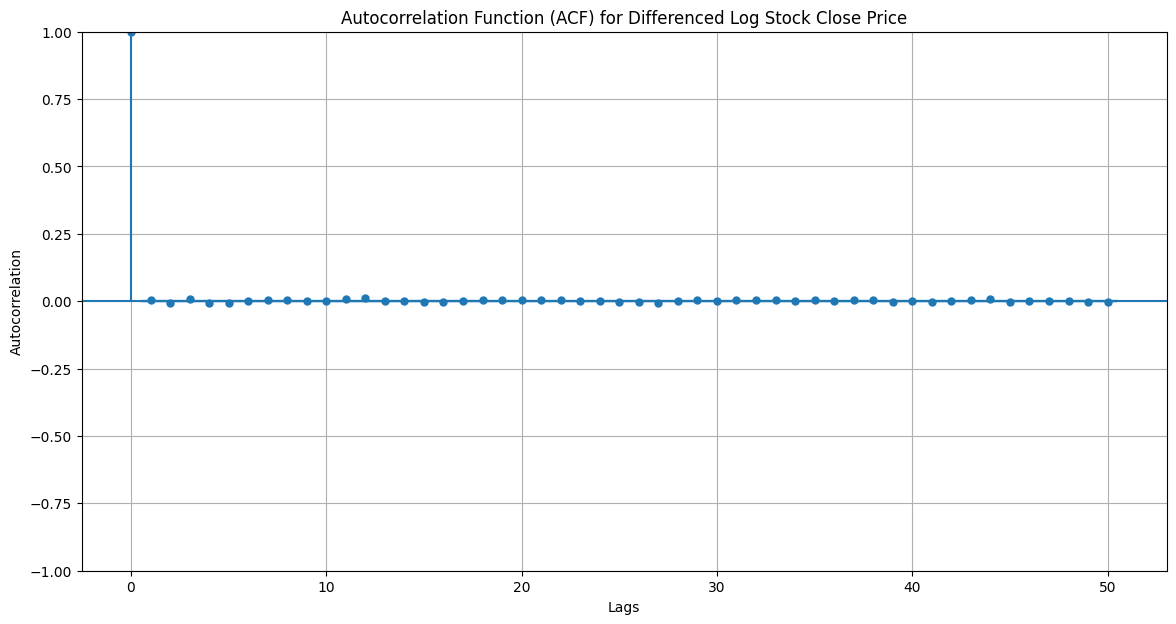

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF for the differenced log series
plt.figure(figsize=(14, 7))
plot_acf(df_log_diff, lags=50, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) for Differenced Log Stock Close Price')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

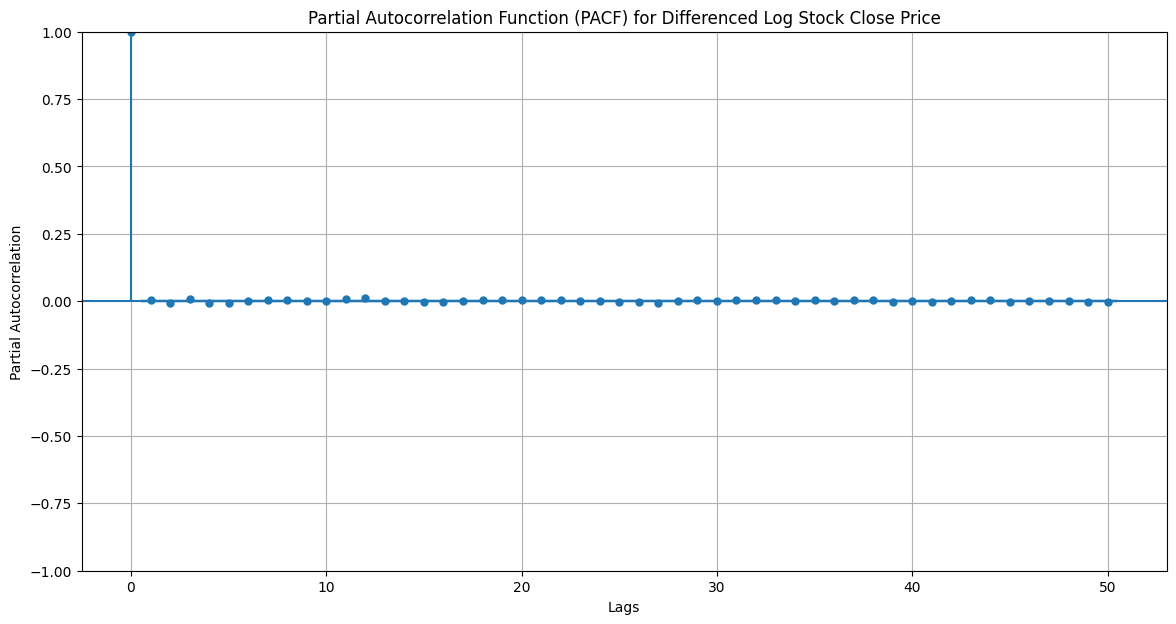

In [ ]:
# Plot PACF for the differenced log series
plt.figure(figsize=(14, 7))
plot_pacf(df_log_diff, lags=50, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) for Differenced Log Stock Close Price')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.5 MB/s eta 0:00:00


In [ ]:
!pip install pmdarima --upgrade

In [ ]:
import pmdarima as pm

# Fit auto_arima to find the best ARIMA order (p, d, q)
# We use the log-transformed and first-differenced series (df_log_diff).
# Since df_log_diff is already differenced, we set d=0 for auto_arima to search for p and q.

print("Searching for optimal ARIMA (p, 0, q) orders using auto_arima on differenced log data...")

# Set seasonal=False for non-seasonal ARIMA
# m=1 for non-seasonal data (or if seasonality is not present / handled separately)
# trace=True to see the search process
# stepwise=True for faster search

model_auto_arima = pm.auto_arima(df_log_diff, # Use the already differenced log series
                                 start_p=1, start_q=1,
                                 max_p=5, max_q=5,
                                 d=0, # Set d=0 because the input data is already differenced
                                 test='adf',    # use adftest to find optimal d (though we fixed it)
                                 seasonal=False,
                                 trace=True,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True,
                                 missing='drop') # Still good practice to keep, just in case

print("\nOptimal ARIMA model: ", model_auto_arima.summary())

Searching for optimal ARIMA (p, 0, q) orders using auto_arima on differenced log data...
Performing stepwise search to minimize aic


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1968: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1973: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-1020303.474, Time=26.37 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1020307.475, Time=4.63 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-1020308.003, Time=8.24 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-1020308.038, Time=12.18 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-1020310.396, Time=16.08 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-1020312.120, Time=19.80 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-1020310.616, Time=25.85 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-1020311.431, Time=25.43 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-1020312.965, Time=21.80 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=-1020313.952, Time=26.55 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=-1020313.258, Time=31.19 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=-1020314.615, Time=31.58 sec
 ARIMA(1,0,5)(0,0,0)[0]             : AIC=-1020311.289, Time=37.04 sec
 ARIMA(0,0,5)(0,0,0)[0] intercept   : AIC=-1020316.218, Time=69.14 sec
 ARIMA(0

### Model Diagnostics

Model diagnostics involve analyzing the residuals of the fitted model to ensure that the model assumptions are met. We typically look for:

1.  **Standardized Residuals**: Should resemble white noise (no trend, constant variance).
2.  **Histogram plus kde estimate**: Residuals should be normally distributed.
3.  **Normal Q-Q**: Quantiles of residuals should lie along the 45-degree line.
4.  **Correlogram (ACF) of Residuals**: No significant autocorrelation in the residuals.

Plotting model diagnostics...


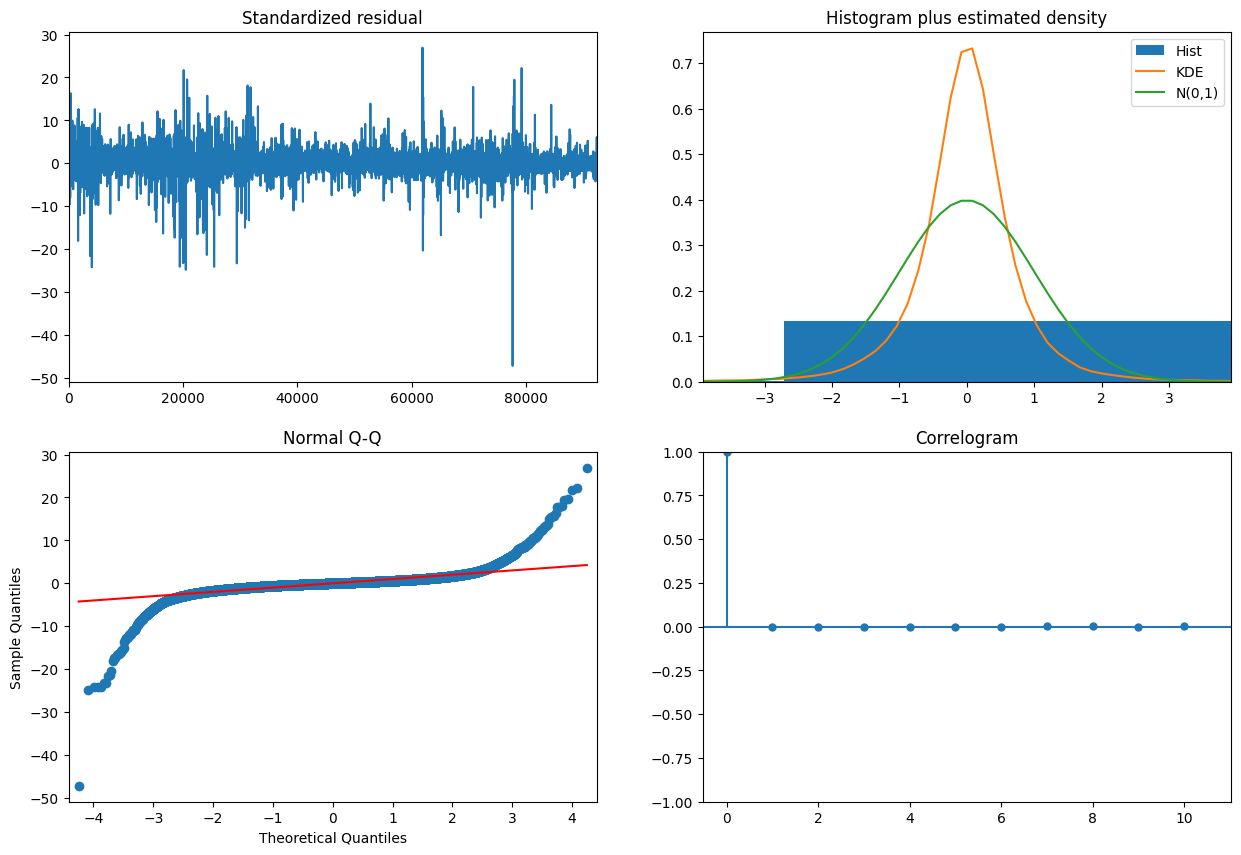

In [ ]:
import matplotlib.pyplot as plt

# Plotting model diagnostics
print('Plotting model diagnostics...')
model_auto_arima.plot_diagnostics(figsize=(15, 10))
plt.show()

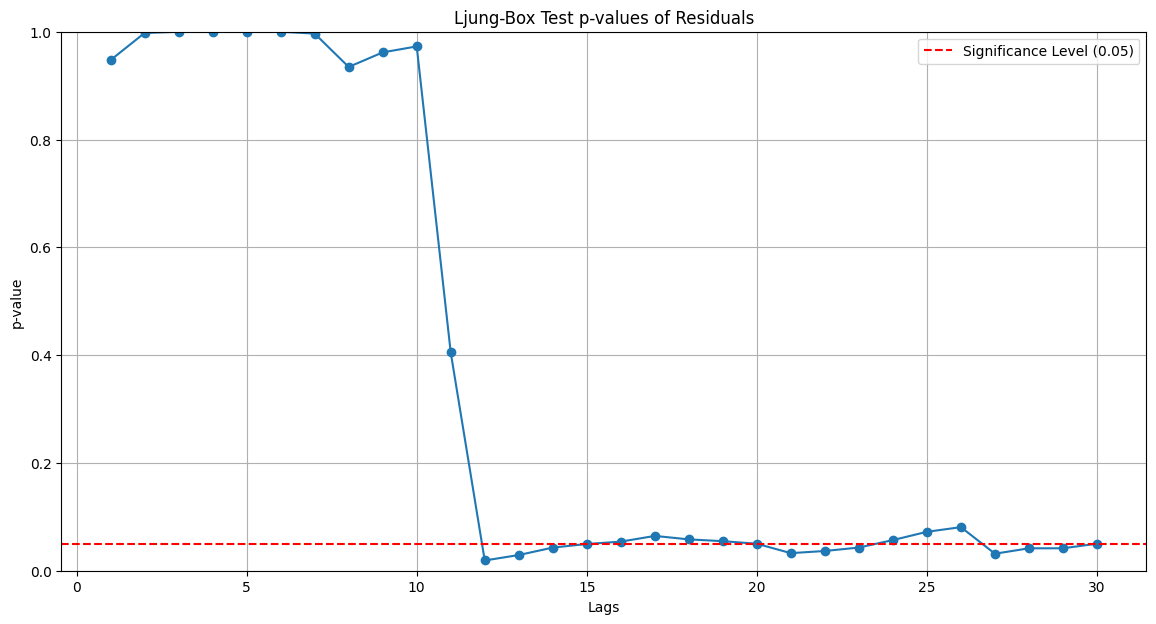

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import numpy as np

# Get the residuals from the fitted auto_arima model
residuals = model_auto_arima.resid()

# Calculate Ljung-Box test for several lags
# The number of lags should ideally be similar to the maximum lag used in ACF/PACF plots, e.g., 20 or 30
lags = np.arange(1, 31) # Testing up to 30 lags

# acorr_ljungbox returns a dataframe with 'lb_pvalue' (Ljung-Box p-value) and 'bp_pvalue' (Box-Pierce p-value)
ljungbox_results = acorr_ljungbox(residuals, lags=lags, return_df=True)

# Plot the p-values
plt.figure(figsize=(14, 7))
plt.plot(ljungbox_results.index, ljungbox_results['lb_pvalue'], marker='o', linestyle='-')
plt.axhline(y=0.05, color='r', linestyle='--', label='Significance Level (0.05)')
plt.title('Ljung-Box Test p-values of Residuals')
plt.xlabel('Lags')
plt.ylabel('p-value')
plt.grid(True)
plt.ylim(0, 1) # p-values are between 0 and 1
plt.legend()
plt.show()

### Forecasting with ARIMA

To perform forecasting, we'll first split our `log_close` series into training and testing sets. We will then fit the ARIMA model on the training data and generate predictions for the test period.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt

# Split data into training and testing sets
# We'll use 80% for training and 20% for testing
train_size = int(len(df['log_close']) * 0.8)
train_data = df['log_close'].iloc[0:train_size]
test_data = df['log_close'].iloc[train_size:]

# Explicitly set frequency for train_data and test_data to ensure statsmodels can use it
# df['log_close'].index.freq should be '5T' from previous steps
if train_data.index.freq is None:
    train_data = train_data.asfreq(df.index.freq)
if test_data.index.freq is None:
    test_data = test_data.asfreq(df.index.freq)

print(f"Training data points: {len(train_data)}")
print(f"Testing data points: {len(test_data)}")

Training data points: 1460
Testing data points: 365


Now, we will fit the ARIMA model using the optimal orders (0, 1, 5) found by `auto_arima` on the training data. Then, we will generate predictions.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the ARIMA(0, 1, 5) model on the training data
# The order is (p, d, q)
model = ARIMA(train_data, order=(0, 1, 5))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              log_close   No. Observations:                 1460
Model:                 ARIMA(0, 1, 5)   Log Likelihood                3179.480
Date:                Tue, 15 Sep 2026   AIC                          -6346.961
Time:                        09:10:52   BIC                          -6315.248
Sample:                    01-25-2021   HQIC                         -6335.130
                         - 01-23-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1882      0.030     -6.282      0.000      -0.247      -0.129
ma.L2         -0.0334      0.040     -0.841      0.400      -0.111       0.044
ma.L3          0.0695      0.042      1.658      0.0

In [ ]:
start_index_for_predict = len(train_data) # This correctly points to the first test observation's index relative to train_data
end_index_for_predict = len(train_data) + len(test_data) - 1 # This points to the last test observation's index relative to train_data

predictions_log = model_fit.predict(start=start_index_for_predict, end=end_index_for_predict)

# The index of predictions_log will be generated by statsmodels. We need to ensure it matches test_data's index for proper alignment.
# It's safer to directly assign the test_data's index to the predictions.
predictions_log.index = test_data.index

# Since we modeled log_close, we need to convert predictions back to the original scale (close price)
predictions = np.exp(predictions_log)
actual_values = np.exp(test_data)

# Display some predictions and actual values
print("Predictions (first 5):")
print(predictions.head())
print("\nActual Values (first 5):")
print(actual_values.head())

Predictions (first 5):
date
2025-01-23 10:15:00+05:30    23137.294948
2025-01-24 10:15:00+05:30    23118.301471
2025-01-25 10:15:00+05:30    23123.474475
2025-01-26 10:15:00+05:30    23118.933975
2025-01-27 10:15:00+05:30    23118.032666
Freq: D, Name: predicted_mean, dtype: float64

Actual Values (first 5):
date
2025-01-23 10:15:00+05:30    23225.75
2025-01-24 10:15:00+05:30    23135.90
2025-01-25 10:15:00+05:30         NaN
2025-01-26 10:15:00+05:30         NaN
2025-01-27 10:15:00+05:30    22900.50
Freq: D, Name: log_close, dtype: float64


### Evaluating the Forecast

We'll evaluate the forecast using metrics like Root Mean Squared Error (RMSE) and visualize the predictions against the actual values.

Test RMSE: 1940.6846


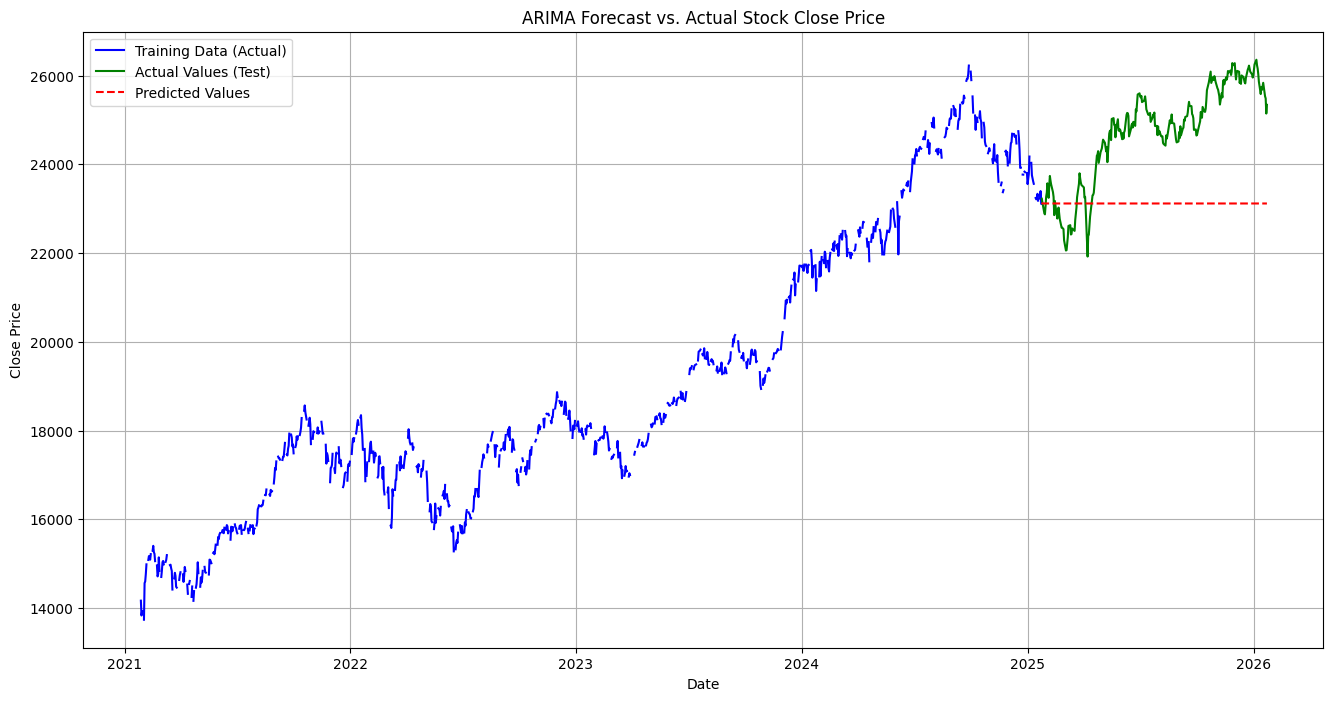

In [ ]:
# Align actual_values and predictions, dropping NaNs
# This is necessary because test_data (and thus actual_values) might have NaNs
# due to resampling or missing days (e.g., weekends/holidays if daily data)
# The predictions will not have NaNs in these corresponding places.
actual_values_cleaned = actual_values.dropna()
predictions_cleaned = predictions[actual_values_cleaned.index]

# Calculate RMSE
rmse = sqrt(mean_squared_error(actual_values_cleaned, predictions_cleaned))
print(f'Test RMSE: {rmse:.4f}')

# For plotting, also use the cleaned data to avoid plotting NaNs
plt.figure(figsize=(16, 8))
plt.plot(train_data.index, np.exp(train_data), label='Training Data (Actual)', color='blue')
plt.plot(actual_values_cleaned.index, actual_values_cleaned, label='Actual Values (Test)', color='green')
plt.plot(predictions_cleaned.index, predictions_cleaned, label='Predicted Values', color='red', linestyle='--')
plt.title('ARIMA Forecast vs. Actual Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

### In-sample vs. Out-of-sample Accuracy

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
from math import sqrt

# Make in-sample predictions
# The start and end indices are relative to the train_data used for fitting the model
in_sample_predictions_log = model_fit.predict(start=0, end=len(train_data) - 1)

# Convert in-sample predictions back to original scale
in_sample_predictions = np.exp(in_sample_predictions_log)

# Calculate in-sample RMSE
# Ensure both series are aligned and handle potential NaNs in train_data if any
in_sample_actual_cleaned = np.exp(train_data).dropna()
in_sample_predictions_cleaned = in_sample_predictions[in_sample_actual_cleaned.index]

in_sample_rmse = sqrt(mean_squared_error(in_sample_actual_cleaned, in_sample_predictions_cleaned))
print(f'In-sample RMSE: {in_sample_rmse:.4f}')
print(f'Out-of-sample (Test) RMSE: {rmse:.4f}')

if in_sample_rmse < rmse:
    print("\nInterpretation: The in-sample RMSE is lower than the out-of-sample RMSE, which is expected. A significantly larger out-of-sample RMSE could indicate overfitting.")
elif in_sample_rmse > rmse:
    print("\nInterpretation: The in-sample RMSE is higher than the out-of-sample RMSE, which is unusual and might suggest issues like underfitting or data leakage.")
else:
    print("\nInterpretation: The in-sample and out-of-sample RMSEs are similar, which could indicate a robust model, but also consider if the test set is too easy or too small.")

In-sample RMSE: 492.6734
Out-of-sample (Test) RMSE: 1940.6846

Interpretation: The in-sample RMSE is lower than the out-of-sample RMSE, which is expected. A significantly larger out-of-sample RMSE could indicate overfitting.
